In [66]:
import pandas as pd
from matplotlib import pyplot as plt
import os
import sys
import numpy as np

In [67]:
current_path = os.getcwd()
cwd = os.path.dirname(current_path)
sys.path.append(os.path.join(cwd, "utilities"))

# Import pickle operations

from pickle_file_operations import read_pickle, write_pickle
from optimization_dataclasses import Optimization_Results
pd.set_option('display.float_format', '{:.3f}'.format)

In [68]:
from tensorflow.keras.models import load_model

In [69]:
folders = ["Unconstrained model", "Constrained model", "FICNN model"]
nn_dict = {}
for folder in folders:
    history_path = os.path.join(cwd, "NN length models", folder)
    nn_dict[folder] = {}
    for nn_model in list(os.scandir(history_path))[:-2]:
        length = nn_model.name.split("_")[0]
        if nn_model.name.split(".")[-1] == "keras":
            length = nn_model.name.split("_")[0]
            nn_dict[folder][length] = load_model(nn_model.path)
        
# history_dict

In [70]:
list(os.scandir(history_path))

[<DirEntry '.ipynb_checkpoints'>,
 <DirEntry '1_layer_Base_NN.keras'>,
 <DirEntry '1_layer_Base_NN.pickle'>,
 <DirEntry '2_layer_Base_NN.keras'>,
 <DirEntry '2_layer_Base_NN.pickle'>,
 <DirEntry '4_layer_Base_NN.keras'>,
 <DirEntry '4_layer_Base_NN.pickle'>,
 <DirEntry '5_layer_Base_NN.keras'>,
 <DirEntry '5_layer_Base_NN.pickle'>,
 <DirEntry '6_layer_Base_NN.keras'>,
 <DirEntry '6_layer_Base_NN.pickle'>,
 <DirEntry 'history_dict.pickle'>,
 <DirEntry 'history_dict_6.pickle'>]

In [71]:
nn_dict

{'Unconstrained model': {'1': <Sequential name=sequential, built=True>,
  '2': <Sequential name=sequential_1, built=True>,
  '4': <Sequential name=sequential_2, built=True>,
  '5': <Sequential name=sequential_3, built=True>,
  '6': <Sequential name=sequential, built=True>},
 'Constrained model': {'1': <Sequential name=sequential_4, built=True>,
  '2': <Sequential name=sequential_5, built=True>,
  '4': <Sequential name=sequential_6, built=True>,
  '5': <Sequential name=sequential_7, built=True>,
  '6': <Sequential name=sequential_1, built=True>},
 'FICNN model': {'1': <Functional name=functional_5, built=True>,
  '2': <Functional name=functional_6, built=True>,
  '4': <Functional name=functional_7, built=True>,
  '5': <Functional name=functional_8, built=True>,
  '6': <Functional name=functional_9, built=True>}}

In [72]:
input_path = os.path.join(cwd, "optimization input")
nn_scaler = read_pickle(os.path.join(input_path, "nn_scaler.pickle"))

In [73]:
nn_scaler

{'x': {'min': 0.098, 'max': 19.541},
 'y': {'min': 0.1, 'max': 20.0},
 'a': {'min': 4.0, 'max': 8.0},
 'b': {'min': 0.25, 'max': 2.0},
 'z': {'min': 0.0, 'max': 741.868}}

In [74]:
def saturation_func(df):
    x = df["flexibility_MWh"]
    y = df["updated_max_flexibility_MWh"]
    a = df["shaping_parameters"][0]
    b = df["shaping_parameters"][1]

    x_new = max(0.098, x)
    y_new = max(0.10, y)
    if y_new / x_new > 1:
        z = (-1 * b) ** -1 * x_new * ((np.log((y_new / x_new) - 1)) - a)
    else:
        x_new = 0.99 * y_new
        z = (-1 * b) ** -1 * x_new * ((np.log((y_new / x_new) - 1)) - a)
        
    z_positive = max(z, 0)
    return round(z_positive, 3)

In [75]:
def calculate_revenue(optimization_results: Optimization_Results): 
    cols = ['flexibility_MWh', 'updated_max_flexibility_MWh',
       'flexibility_cost_DKK', 'market_price', 'shaping_parameters',
       'actual_flexibility_cost_DKK', 'net_revenue', "square_error"]
    df = optimization_results.decision_variables
    if not df.empty:
        df["actual_flexibility_cost_DKK"] = df.apply(saturation_func, axis=1)
        df["net_revenue"] = df.market_price * df.flexibility_MWh - df.actual_flexibility_cost_DKK
        df["square_error"] = (df.actual_flexibility_cost_DKK - df.flexibility_cost_DKK)** 2
    else:
        df = pd.DataFrame(columns=cols)
    return df

def calculate_nn_revenue(optimization_results: Optimization_Results, nn_model, nn_scaler):
    df = optimization_results.decision_variables
    x_unscaled = df["flexibility_MWh"].values
    y_unscaled = df["updated_max_flexibility_MWh"].values
    a_unscaled, b_unscaled = np.array([[i, j]  for (i, j) in df["shaping_parameters"].values]).transpose()
    x = (df["flexibility_MWh"].values -  nn_scaler["x"]["min"]) / (nn_scaler["x"]["max"] -  nn_scaler["x"]["min"])
    y = (df["updated_max_flexibility_MWh"].values -  nn_scaler["y"]["min"]) / (nn_scaler["y"]["max"] -  nn_scaler["y"]["min"])
    a = (a_unscaled -  nn_scaler["a"]["min"]) / (nn_scaler["a"]["max"] -  nn_scaler["a"]["min"])
    b = (b_unscaled -  nn_scaler["x"]["min"]) / (nn_scaler["x"]["max"] -  nn_scaler["x"]["min"])    
    input_data = np.array([x, y, a, b]).transpose()
    output_data = nn_model.predict(input_data)
    output_data_unscaled = (nn_scaler["z"]["max"] - nn_scaler["z"]["min"]) * output_data.transpose()[0] + nn_scaler["z"]["min"]
    df["NN_estimated_flexibility_cost_DKK"] = np.maximum(output_data_unscaled, 0)
    df["NN_square_error"] = (df.NN_estimated_flexibility_cost_DKK - df.flexibility_cost_DKK)** 2
    return df
    
def results_summary(optimization_results: Optimization_Results): 

    df = optimization_results.decision_variables
    solve_check = 100 * round(optimization_results.mip_gap, 3) <= 1.0
    
    summary_dict = {"objective_value": df.net_revenue.sum(), 
                    "mean_square_error": df.square_error.mean(),
                    # "NN_mean_square_error": df.NN_square_error.mean(),
                    "runtime": optimization_results.runtime, 
                    "cpu_time": optimization_results.cpu_time, 
                    "mip_gap": 100 * round(optimization_results.mip_gap, 3), 
                    "solve_check": solve_check}
    return pd.DataFrame(summary_dict, index=[0])

In [76]:
results_path = os.path.join(cwd, "length results")
folders = ["Gurobi ML", "Proposed", "FICNN"]
summary_cols = ["objective_value", "mean_square_error", 
                # "NN_mean_square_error", 
                "runtime", "cpu_time", "mip_gap", "solve_check", 
                "length", "methodology", "scenario_type", "case"]

In [110]:
summary_tables = pd.DataFrame(columns = summary_cols)
index = 0
for folder in folders:
    filepath = os.path.join(results_path, folder)
    if folder == "Proposed":
        folder_name = "ICNN 1"
        nn_folder = "Unconstrained model"
    elif folder == "FICNN":
        folder_name = "ICNN 2"
        nn_folder = "FICNN model"
    else:
        folder_name = folder
        nn_folder = "Constrained model"
    for filename in list(os.listdir(filepath)):
        length = filename.split("_")[0]
        file_path = os.path.join(filepath, filename)
        data = read_pickle(file_path)
        for scenario, scenario_results in data.items():
            if scenario == "Low_prices":
                for case, results in scenario_results.items():
                    scenario_results[case].decision_variables = calculate_revenue(results)
                    scenario_results[case].decision_variables = calculate_nn_revenue(results, nn_dict[nn_folder][length], nn_scaler)
                    # # write_pickle(data, os.path.join(filepath, "Results_with_revenue.pickle"))
                    result_row = results_summary(results)
                    result_row[summary_cols[-4:]] = [length, folder_name, scenario, case]
                    summary_tables.loc[len(summary_tables)] = result_row.values[0]
                    index = index + 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━

In [111]:
summary_tables[summary_tables.methodology == "NWLP"]["NN_mean_square_error"]

KeyError: 'NN_mean_square_error'

In [112]:
best_cases_df = read_pickle("length_best_cases_df.pickle")

In [113]:
summary_tables = pd.concat([summary_tables, best_cases_df[summary_cols]], ignore_index=True)

In [114]:
summary_tables

,objective_value,mean_square_error,runtime,cpu_time,mip_gap,solve_check,length,methodology,scenario_type,case
0,108.222,1.654,4.951,13.281,0.000,True,1,Gurobi ML,Low_prices,0
1,562.481,1.835,5.742,18.766,0.500,True,1,Gurobi ML,Low_prices,1
2,485.326,1.873,4.396,11.438,0.900,True,1,Gurobi ML,Low_prices,2
3,281.533,2.285,6.440,19.953,0.500,True,1,Gurobi ML,Low_prices,3
4,178.569,12.679,3.061,9.750,1.000,True,1,Gurobi ML,Low_prices,4
...,...,...,...,...,...,...,...,...,...,...
245,92.003,2435.728,0.008,0.000,0,True,6,PCTAR,Low_prices,5
246,-996.451,14110.316,0.008,0.016,0,True,6,PCTAR,Low_prices,6
247,-926.159,14143.206,0.010,0.000,0,True,6,PCTAR,Low_prices,7
248,-975.302,14159.924,0.010,0.016,0,True,6,PCTAR,Low_prices,8


In [115]:
summary_tables["infeasible"] = summary_tables["mip_gap"] == 100000000
summary_tables

,objective_value,mean_square_error,runtime,cpu_time,mip_gap,solve_check,length,methodology,scenario_type,case,infeasible
0,108.222,1.654,4.951,13.281,0.000,True,1,Gurobi ML,Low_prices,0,False
1,562.481,1.835,5.742,18.766,0.500,True,1,Gurobi ML,Low_prices,1,False
2,485.326,1.873,4.396,11.438,0.900,True,1,Gurobi ML,Low_prices,2,False
3,281.533,2.285,6.440,19.953,0.500,True,1,Gurobi ML,Low_prices,3,False
4,178.569,12.679,3.061,9.750,1.000,True,1,Gurobi ML,Low_prices,4,False
...,...,...,...,...,...,...,...,...,...,...,...
245,92.003,2435.728,0.008,0.000,0,True,6,PCTAR,Low_prices,5,False
246,-996.451,14110.316,0.008,0.016,0,True,6,PCTAR,Low_prices,6,False
247,-926.159,14143.206,0.010,0.000,0,True,6,PCTAR,Low_prices,7,False
248,-975.302,14159.924,0.010,0.016,0,True,6,PCTAR,Low_prices,8,False


In [116]:
write_pickle(summary_tables, "length_summmary_tables.pickle")

In [117]:
method_masks = {folder: summary_tables.methodology == folder for folder in folders}
scenario_masks = {scenario: summary_tables.scenario_type == scenario for scenario in summary_tables.scenario_type.unique()}

combined_masks = {folder + " " + scenario: mask1 & mask2
                  for folder, mask1 in method_masks.items() 
                  for scenario, mask2 in scenario_masks.items()}
mean_cols = summary_cols[0: -5]

In [118]:
mean_cols

['objective_value', 'mean_square_error', 'runtime', 'cpu_time', 'mip_gap']

In [119]:
df = summary_tables.groupby(["length", "methodology"])[mean_cols].mean()
df = df.map(lambda x: f"{x:.3f}" if isinstance(x, (int, float)) else x)
df

objective_value mean_square_error   runtime   cpu_time  \
length methodology                                                          
1      Gurobi ML           233.845             2.570     4.387     14.806   
       ICNN 1              238.586            24.778     0.018      0.030   
       ICNN 2              237.415            27.033     0.018      0.002   
       PCAR               -358.605           249.403     0.013      0.014   
       PCTAR              -358.605           249.403     0.027      0.033   
2      Gurobi ML           233.102             7.467    86.772    679.609   
       ICNN 1              236.798            27.632     0.030      0.039   
       ICNN 2              236.786            29.328     0.025      0.002   
       PCAR               -117.741           854.373     0.038      0.039   
       PCTAR              -117.741           854.373     0.070      0.070   
4      Gurobi ML           209.165            96.075    53.257    408.613   
       ICNN 1              233.819            36.197     0.027      0.045   
       ICNN 2              225.212            32.954     0.036      0.011   
       PCAR                106.531          1022.042     0.037      0.041   
       PCTAR               106.531          1022.042     0.059      0.060   
5      Gurobi ML           156.376           438.939  3600.377  14708.464   
       ICNN 1              219.307            53.503     0.035      0.041   
       ICNN 2              232.107            28.801     0.035      0.002   
       PCAR                 46.756           544.034     0.012      0.011   
       PCTAR                46.756           544.034     0.032      0.028   
6      Gurobi ML            14.735           913.696     0.077      0.128   
       ICNN 1              220.025            53.680     0.031      0.042   
       ICNN 2              210.219            67.622     0.044      0.011   
       PCAR               -679.933         73135.239     0.008      0.014   
       PCTAR              -679.933         73012.117     0.011      0.008   

                   mip_gap  
length methodology          
1      Gurobi ML     0.600  
       ICNN 1        0.000  
       ICNN 2        0.000  
       PCAR          0.000  
       PCTAR         0.000  
2      Gurobi ML     0.560  
       ICNN 1        0.000  
       ICNN 2        0.000  
       PCAR          0.000  
       PCTAR         0.000  
4      Gurobi ML     0.600  
       ICNN 1        0.000  
       ICNN 2        0.000  
       PCAR          0.000  
       PCTAR         0.000  
5      Gurobi ML    54.560  
       ICNN 1        0.000  
       ICNN 2        0.000  
       PCAR          0.000  
       PCTAR         0.000  
6      Gurobi ML     0.000  
       ICNN 1        0.000  
       ICNN 2        0.000  
       PCAR          0.000  
       PCTAR         0.000

In [120]:
latex_code = df.to_latex()
print(latex_code)

\begin{tabular}{lllllll}
\toprule
 &  & objective_value & mean_square_error & runtime & cpu_time & mip_gap \\
length & methodology &  &  &  &  &  \\
\midrule
\multirow[t]{5}{*}{1} & Gurobi ML & 233.845 & 2.570 & 4.387 & 14.806 & 0.600 \\
 & ICNN 1 & 238.586 & 24.778 & 0.018 & 0.030 & 0.000 \\
 & ICNN 2 & 237.415 & 27.033 & 0.018 & 0.002 & 0.000 \\
 & PCAR & -358.605 & 249.403 & 0.013 & 0.014 & 0.000 \\
 & PCTAR & -358.605 & 249.403 & 0.027 & 0.033 & 0.000 \\
\cline{1-7}
\multirow[t]{5}{*}{2} & Gurobi ML & 233.102 & 7.467 & 86.772 & 679.609 & 0.560 \\
 & ICNN 1 & 236.798 & 27.632 & 0.030 & 0.039 & 0.000 \\
 & ICNN 2 & 236.786 & 29.328 & 0.025 & 0.002 & 0.000 \\
 & PCAR & -117.741 & 854.373 & 0.038 & 0.039 & 0.000 \\
 & PCTAR & -117.741 & 854.373 & 0.070 & 0.070 & 0.000 \\
\cline{1-7}
\multirow[t]{5}{*}{4} & Gurobi ML & 209.165 & 96.075 & 53.257 & 408.613 & 0.600 \\
 & ICNN 1 & 233.819 & 36.197 & 0.027 & 0.045 & 0.000 \\
 & ICNN 2 & 225.212 & 32.954 & 0.036 & 0.011 & 0.000 \\
 & PCAR & 1

In [121]:
(summary_tables.groupby(["length", "methodology"])["infeasible"].sum())

length  methodology
1       Gurobi ML      0
        ICNN 1         0
        ICNN 2         0
        PCAR           0
        PCTAR          0
2       Gurobi ML      0
        ICNN 1         0
        ICNN 2         0
        PCAR           0
        PCTAR          0
4       Gurobi ML      0
        ICNN 1         0
        ICNN 2         0
        PCAR           0
        PCTAR          0
5       Gurobi ML      0
        ICNN 1         0
        ICNN 2         0
        PCAR           0
        PCTAR          0
6       Gurobi ML      0
        ICNN 1         0
        ICNN 2         0
        PCAR           0
        PCTAR          0
Name: infeasible, dtype: int64

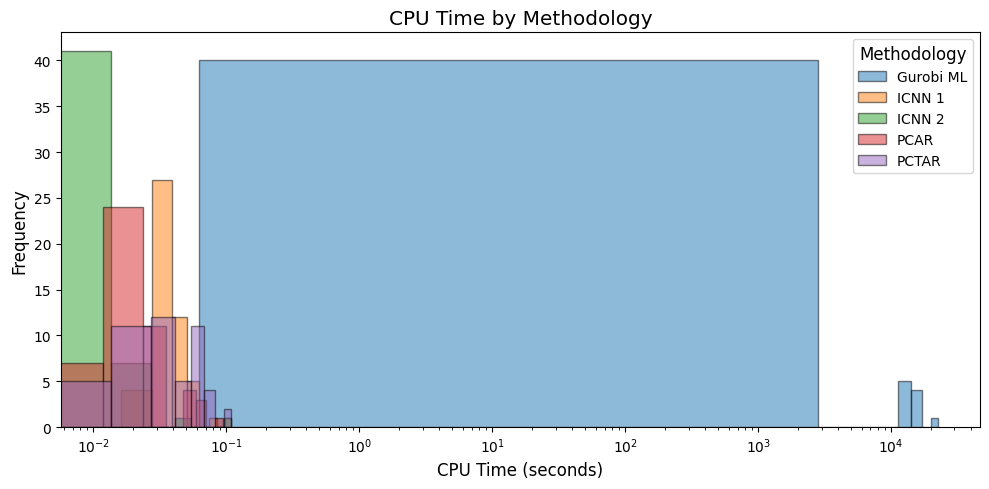

In [122]:
grouped_df = summary_tables.groupby("methodology")["cpu_time"]
# Create a single figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot histograms on the same axis with log scale for x-axis
for name, group in grouped_df:
    n, bins, patches = ax.hist(group, bins=8, alpha=0.5, label=name, edgecolor='black')

ax.set_title('CPU Time by Methodology', fontsize="x-large")
ax.set_xlabel('CPU Time (seconds)', fontsize="large")
ax.set_ylabel('Frequency', fontsize="large")

# Set x-axis to log scale
ax.set_xscale('log')

# Add legend to differentiate methodologies
ax.legend(title="Methodology", fontsize="medium", title_fontsize="large")

plt.tight_layout()
plt.show()

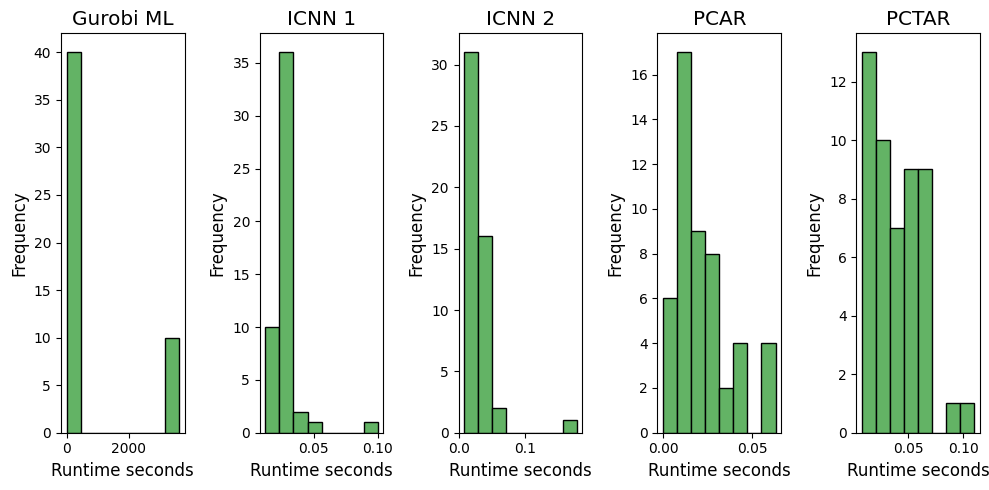

In [123]:
grouped_df = summary_tables.groupby("methodology")["runtime"]
fig, axes = plt.subplots(1, 5, figsize=(10, 5))  # 12 months, 3x4 grid
axes = axes.ravel()  # Flattening the axes array for easy indexing

for i, (name, group) in enumerate(grouped_df):
    n, bins, patches = axes[i].hist(group, bins=8, color='xkcd:boring green', edgecolor='black')
    
    # Get dynamic x-ticks
    max_bin = np.ceil(max(bins))
    min_bin = np.floor(min(bins))
    xticks = np.linspace(min_bin, max_bin, 4, dtype=float)
    axes[i].set_title(name, fontsize="x-large")
    axes[i].set_xlabel('Runtime seconds', fontsize="large")
    axes[i].set_ylabel('Frequency', fontsize="large")
    # axes[i].set_xticks(xticks)

# Adjust layout to avoid overlapping
plt.tight_layout()
plt.savefig(os.path.join(cwd, "images", "runtime_histograms.png"))
plt.show()

In [ ]:
grouped_df = summary_tables.groupby("methodology")["runtime"]
fig, ax = plt.subplots(figsize=(5, 3))
colors =  xkcd_palette = ['xkcd:black', 'xkcd:blue', 'xkcd:orange', 'xkcd:green', 'xkcd:red', 'xkcd:purple', 'xkcd:grey']

# Plot histograms on the same axis with log scale for x-axis
for i, (name, group) in enumerate(list(grouped_df)):
    n, bins, patches = ax.hist(group, bins=5, alpha=0.8, label=name, edgecolor=colors[i % len(colors)], histtype="step", linewidth=2)

# ax.set_title('Run Time by Methodology', fontsize="x-large")
ax.set_xlabel('Run Time (seconds)', fontsize="large")
ax.set_ylabel('Frequency', fontsize="large")

# Set x-axis to log scale
ax.set_xscale('log')

# Set x and y axis lims
ax.set_ylim([0, 25])

# Add legend to differentiate methodologies
ax.legend(ncols=3, fontsize="medium", title_fontsize="large")

plt.grid(zorder=0, alpha=0.6)
plt.show()

In [ ]:
grouped_df = summary_tables.groupby("methodology")["cpu_time"]
fig, ax = plt.subplots(figsize=(5, 3))
colors = ['xkcd:black', 'xkcd:blue', 'xkcd:orange', 'xkcd:green', 'xkcd:red', 'xkcd:purple', 'xkcd:grey']

# Plot histograms on the same axis with log scale for x-axis
for i, (name, group) in enumerate(list(grouped_df)):
    if i != 0:
        n, bins, patches = ax.hist(group, bins=5, alpha=0.7, label=name, edgecolor=colors[i % len(colors)], histtype="step", linewidth=2)

# ax.set_title('Run Time by Methodology', fontsize="x-large")
ax.set_xlabel('CPU run Time (seconds)', fontsize="large")
ax.set_ylabel('Frequency', fontsize="large")

# Set x-axis to log scale
ax.set_xscale('log')

# Set x and y axis lims
ax.set_ylim([0, 30])

# Add legend to differentiate methodologies
ax.legend(ncols = 3, fontsize="medium", title_fontsize="large")
plt.grid(zorder=0, alpha=0.6)
plt.show()